In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv('IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
#convert the positive and negative reviews to 1 and 0
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

df['sentiment'] = encoder.fit_transform(df['sentiment'])
df['sentiment']

,sentiment
0,1
1,1
2,1
3,0
4,1
...,...
49995,1
49996,0
49997,0
49998,0


In [5]:
#select the input and target variable
x = df['review'].values

y = df['sentiment'].values

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

In [8]:
VOCAB_SIZE = 10000   #max 10000 words will be there in vocabulary
MAX_LEN = 200  #max 200 tokens per input

In [11]:
#Tokenization

#1.import Tokenizer and create a tokenizer object
from tensorflow.keras.preprocessing.text import Tokenizer
tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')

#2.fit the training data on this tokenizer object
tokenizer.fit_on_texts(x_train)

#3.convert the training text data to sequence of integers
x_train_seq = tokenizer.texts_to_sequences(x_train)

#4.convert the testing text data to sequence of integers
x_test_seq = tokenizer.texts_to_sequences(x_test)

In [12]:
#Padding

#import padding library/model whatever the fuck it is
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_padded = pad_sequences(x_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_padded = pad_sequences(x_test_seq, maxlen=MAX_LEN, padding='post', truncating='post')

In [13]:
#Creating the model finallyyyy
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, Flatten

model = Sequential()

model.add(Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAX_LEN))

model.add(Flatten())

model.add(Dense(64, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [14]:
#Training the model
history = model.fit(
    x_train_padded, y_train,
    batch_size=32,
    epochs=10,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.7979 - loss: 0.4148 - val_accuracy: 0.8566 - val_loss: 0.3223
Epoch 2/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.9547 - loss: 0.1225 - val_accuracy: 0.8280 - val_loss: 0.4623
Epoch 3/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9930 - loss: 0.0210 - val_accuracy: 0.8271 - val_loss: 0.7499
Epoch 4/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.9984 - loss: 0.0055 - val_accuracy: 0.8349 - val_loss: 0.8624
Epoch 5/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 41s 25ms/step - accuracy: 0.9980 - loss: 0.0070 - val_accuracy: 0.8300 - val_loss: 1.0080
Epoch 6/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 24s 24ms/step - accuracy: 0.9910 - loss: 0.0268 - val_accuracy: 0.8231 - val_loss: 0.8926
Epoch 7/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 25s 26ms/step - accuracy: 0.9972 - loss: 0.0076 - val_accuracy: 0.8311 - val_loss: 1.0510
Epoch 8/10
985/985 ━━━━━━━━━━━━━━━━━━━━ 41s 26ms/step - accuracy: 0.9981 - loss: 0.0046 - 

In [15]:
#Evaluating the model
loss, accuracy = model.evaluate(x_test_padded, y_test, verbose=1)

print("The loss is: ", loss)
print("The accuracy is: ", accuracy)

469/469 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.8296 - loss: 1.1905
The loss is:  1.1904503107070923
The accuracy is:  0.8295999765396118


In [16]:
#Converting the found probabilities into final 0 or 1
y_pred_prob = model.predict(x_test_padded)

y_pred = (y_pred_prob > 0.5).astype(int)

469/469 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step


<function matplotlib.pyplot.show(close=None, block=None)>

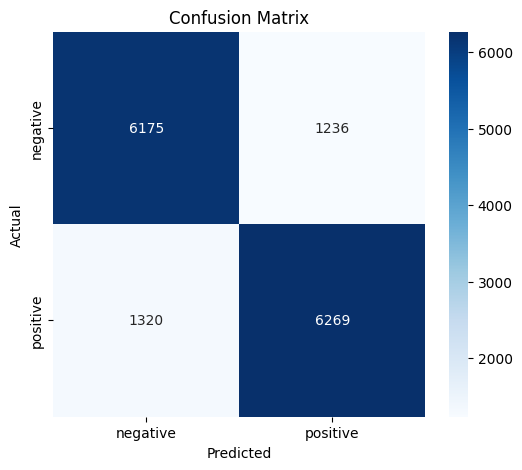

In [25]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot = True, fmt='d', cmap = 'Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show

In [26]:
print('Classification report:')
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Classification report:
              precision    recall  f1-score   support

    negative       0.82      0.83      0.83      7411
    positive       0.84      0.83      0.83      7589

    accuracy                           0.83     15000
   macro avg       0.83      0.83      0.83     15000
weighted avg       0.83      0.83      0.83     15000

